## 0. Setup
Imports, GPU check, output directories.

In [1]:
import os, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

DATA_ROOT = Path('/kaggle/input/datasets/qasimmaajid/communisign-processed-alphabets')
OUT  = Path('/kaggle/working')
MODEL_OUT = OUT / 'models'
LOG_OUT   = OUT / 'logs'
MODEL_OUT.mkdir(parents=True, exist_ok=True)
LOG_OUT.mkdir(parents=True, exist_ok=True)

print('TF version:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))
print('Data root exists:', DATA_ROOT.exists())

2026-05-01 11:41:52.506121: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777635712.684784      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777635712.740702      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777635713.196255      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777635713.196305      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777635713.196308      57 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Data root exists: True


## 1. Load data and drop NOTHING


In [2]:
df = pd.read_pickle(DATA_ROOT / 'alphabet_landmarks.pkl')
with open(DATA_ROOT / 'alphabet_splits.pkl', 'rb') as f:
    splits = pickle.load(f)

print('Total samples (before drop):', len(df))
print('Class counts (before drop):')
print(df['label'].value_counts().sort_index())

# Drop NOTHING — keep its indices for split adjustment
nothing_mask = df['label'] == 'NOTHING'
kept_indices = df.index[~nothing_mask].to_numpy()
df = df[~nothing_mask].reset_index(drop=False)
df = df.rename(columns={'index': 'orig_idx'})

print(f'\nAfter dropping NOTHING: {len(df)} samples, {df["label"].nunique()} classes')

Total samples (before drop): 11089
Class counts (before drop):
label
A          348
B          364
C          341
D          409
DELETE     307
E          398
F          476
G          400
H          395
I          394
J          430
K          455
L          425
M          271
N          205
NOTHING    500
O          382
P          329
Q          355
R          417
S          428
SPACE      272
T          387
U          420
V          414
W          400
X          363
Y          423
Z          381
Name: count, dtype: int64

After dropping NOTHING: 10589 samples, 28 classes


## 2. Apply the saved train/val/test splits


In [3]:
orig_to_new = {orig: new for new, orig in enumerate(kept_indices)}

def remap(idx_list):
    return np.array([orig_to_new[i] for i in idx_list if i in orig_to_new])

train_idx = remap(splits['train_idx'])
val_idx   = remap(splits['val_idx'])
test_idx  = remap(splits['test_idx'])
print(f'train: {len(train_idx)}, val: {len(val_idx)}, test: {len(test_idx)}')

train: 8471, val: 1059, test: 1059


## 3. Encode string labels to integers


In [4]:
labels_sorted = sorted(df['label'].unique())
label_to_idx = {lab: i for i, lab in enumerate(labels_sorted)}
idx_to_label = {i: lab for lab, i in label_to_idx.items()}

df['y'] = df['label'].map(label_to_idx)
X = np.stack(df['features'].values)        # (N, 63)
y = df['y'].to_numpy()

X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print('Classes:', labels_sorted)
print(f'NUM_CLASSES = {len(labels_sorted)}')
print(f'Shapes — X_train: {X_train.shape}, y_train: {y_train.shape}')

# Save the label encoder for the server
with open(MODEL_OUT / 'label_encoder.pkl', 'wb') as f:
    pickle.dump({'label_to_idx': label_to_idx, 'idx_to_label': idx_to_label}, f)

Classes: ['A', 'B', 'C', 'D', 'DELETE', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'SPACE', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
NUM_CLASSES = 28
Shapes — X_train: (8471, 63), y_train: (8471,)


## 4. Class weights


In [5]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print('Class weights (highest 5 — these classes get most loss attention):')
sorted_weights = sorted(class_weight_dict.items(), key=lambda x: x[1], reverse=True)
for cls, w in sorted_weights[:5]:
    print(f'  {idx_to_label[cls]:8s} weight={w:.3f}')

Class weights (highest 5 — these classes get most loss attention):
  N        weight=1.845
  M        weight=1.394
  SPACE    weight=1.388
  DELETE   weight=1.230
  P        weight=1.150


## 5. Data augmentation pipeline


In [6]:
def augment_landmarks(features, label):
    coords = tf.reshape(features, (21, 3))
    # Random rotation in xy plane
    angle = tf.random.uniform([], -0.26, 0.26)  # ~±15°
    cos_a, sin_a = tf.cos(angle), tf.sin(angle)
    x = coords[:, 0] * cos_a - coords[:, 1] * sin_a
    y_ = coords[:, 0] * sin_a + coords[:, 1] * cos_a
    coords = tf.stack([x, y_, coords[:, 2]], axis=1)
    # Random scale
    scale = tf.random.uniform([], 0.9, 1.1)
    coords *= scale
    # Random translation
    shift = tf.random.uniform([3], -0.05, 0.05)
    coords += shift
    # Light additive Gaussian noise — helps with real-world MediaPipe jitter
    coords += tf.random.normal(tf.shape(coords), stddev=0.01)
    return tf.reshape(coords, (63,)), label

BATCH = 256
train_ds = (tf.data.Dataset.from_tensor_slices((X_train.astype(np.float32), y_train))
            .map(augment_landmarks, num_parallel_calls=tf.data.AUTOTUNE)
            .shuffle(8192).batch(BATCH).prefetch(tf.data.AUTOTUNE))
val_ds   = (tf.data.Dataset.from_tensor_slices((X_val.astype(np.float32), y_val))
            .batch(BATCH).prefetch(tf.data.AUTOTUNE))
print('train_ds:', train_ds)

I0000 00:00:1777635763.954301      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777635763.960267      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


train_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 63), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


## 6. Model architecture


In [7]:
NUM_CLASSES = len(labels_sorted)

model = keras.Sequential([
    keras.layers.Input(shape=(63,)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(NUM_CLASSES, activation='softmax'),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 28)             │         1,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,892 (237.86 KB)

 Trainable params: 60,124 (234.86 KB)

 Non-trainable params: 768 (3.00 KB)

## 7. Train


In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                   restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4,
                                       min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(str(MODEL_OUT / 'alphabet_model.h5'),
                                     monitor='val_accuracy', save_best_only=True),
    keras.callbacks.CSVLogger(str(LOG_OUT / 'alphabet_training.csv')),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/80


I0000 00:00:1777635783.818695     126 service.cc:152] XLA service 0x7cf6b4010f50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777635783.818741     126 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777635783.818746     126 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777635784.222223     126 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777635786.567623     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


34/34 - 8s - 243ms/step - accuracy: 0.4370 - loss: 2.1564 - val_accuracy: 0.4183 - val_loss: 2.9544 - learning_rate: 1.0000e-03
Epoch 2/80
34/34 - 1s - 15ms/step - accuracy: 0.7900 - loss: 0.8075 - val_accuracy: 0.3437 - val_loss: 2.6169 - learning_rate: 1.0000e-03
Epoch 3/80
34/34 - 0s - 15ms/step - accuracy: 0.8701 - loss: 0.4877 - val_accuracy: 0.3050 - val_loss: 2.4043 - learning_rate: 1.0000e-03
Epoch 4/80
34/34 - 0s - 14ms/step - accuracy: 0.8900 - loss: 0.3840 - val_accuracy: 0.3097 - val_loss: 2.1830 - learning_rate: 1.0000e-03
Epoch 5/80
34/34 - 0s - 14ms/step - accuracy: 0.9126 - loss: 0.3205 - val_accuracy: 0.2993 - val_loss: 2.0177 - learning_rate: 1.0000e-03
Epoch 6/80
34/34 - 0s - 14ms/step - accuracy: 0.9250 - loss: 0.2679 - val_accuracy: 0.3371 - val_loss: 1.8022 - learning_rate: 1.0000e-03
Epoch 7/80


34/34 - 1s - 15ms/step - accuracy: 0.9359 - loss: 0.2474 - val_accuracy: 0.4835 - val_loss: 1.4632 - learning_rate: 1.0000e-03
Epoch 8/80


34/34 - 1s - 15ms/step - accuracy: 0.9370 - loss: 0.2314 - val_accuracy: 0.6478 - val_loss: 1.1600 - learning_rate: 1.0000e-03
Epoch 9/80


...

34/34 - 1s - 15ms/step - accuracy: 0.9561 - loss: 0.1454 - val_accuracy: 0.9792 - val_loss: 0.0801 - learning_rate: 1.0000e-03
Epoch 20/80
34/34 - 0s - 14ms/step - accuracy: 0.9576 - loss: 0.1424 - val_accuracy: 0.9754 - val_loss: 0.0853 - learning_rate: 1.0000e-03
Epoch 21/80
34/34 - 0s - 14ms/step - accuracy: 0.9599 - loss: 0.1350 - val_accuracy: 0.9754 - val_loss: 0.0869 - learning_rate: 1.0000e-03
Epoch 22/80
34/34 - 0s - 14ms/step - accuracy: 0.9609 - loss: 0.1362 - val_accuracy: 0.9792 - val_loss: 0.0827 - learning_rate: 1.0000e-03
Epoch 23/80

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
34/34 - 0s - 14ms/step - accuracy: 0.9534 - loss: 0.1515 - val_accuracy: 0.9745 - val_loss: 0.0945 - learning_rate: 1.0000e-03
Epoch 24/80
34/34 - 0s - 14ms/step - accuracy: 0.9622 - loss: 0.1293 - val_accuracy: 0.9726 - val_loss: 0.0934 - learning_rate: 5.0000e-04
Epoch 25/80
34/34 - 0s - 13ms/step - accuracy: 0.9664 - loss: 0.1145 - val_accuracy: 0.9783 - val_lo

34/34 - 1s - 16ms/step - accuracy: 0.9701 - loss: 0.1023 - val_accuracy: 0.9802 - val_loss: 0.0742 - learning_rate: 5.0000e-04
Epoch 29/80


34/34 - 1s - 15ms/step - accuracy: 0.9697 - loss: 0.0976 - val_accuracy: 0.9811 - val_loss: 0.0723 - learning_rate: 5.0000e-04
Epoch 30/80


34/34 - 1s - 15ms/step - accuracy: 0.9705 - loss: 0.1061 - val_accuracy: 0.9821 - val_loss: 0.0731 - learning_rate: 5.0000e-04
Epoch 31/80
34/34 - 0s - 14ms/step - accuracy: 0.9677 - loss: 0.1058 - val_accuracy: 0.9811 - val_loss: 0.0716 - learning_rate: 5.0000e-04
Epoch 32/80
34/34 - 0s - 14ms/step - accuracy: 0.9699 - loss: 0.0993 - val_accuracy: 0.9811 - val_loss: 0.0739 - learning_rate: 5.0000e-04
Epoch 33/80


34/34 - 0s - 15ms/step - accuracy: 0.9694 - loss: 0.1023 - val_accuracy: 0.9849 - val_loss: 0.0748 - learning_rate: 5.0000e-04
Epoch 34/80
34/34 - 0s - 14ms/step - accuracy: 0.9720 - loss: 0.0960 - val_accuracy: 0.9821 - val_loss: 0.0764 - learning_rate: 5.0000e-04
Epoch 35/80
34/34 - 0s - 13ms/step - accuracy: 0.9733 - loss: 0.0901 - val_accuracy: 0.9830 - val_loss: 0.0653 - learning_rate: 5.0000e-04
Epoch 36/80
34/34 - 1s - 18ms/step - accuracy: 0.9740 - loss: 0.0900 - val_accuracy: 0.9830 - val_loss: 0.0647 - learning_rate: 5.0000e-04
Epoch 37/80
34/34 - 0s - 14ms/step - accuracy: 0.9713 - loss: 0.0979 - val_accuracy: 0.9811 - val_loss: 0.0735 - learning_rate: 5.0000e-04
Epoch 38/80
34/34 - 0s - 13ms/step - accuracy: 0.9739 - loss: 0.0894 - val_accuracy: 0.9839 - val_loss: 0.0684 - learning_rate: 5.0000e-04
Epoch 39/80
34/34 - 0s - 13ms/step - accuracy: 0.9717 - loss: 0.0952 - val_accuracy: 0.9849 - val_loss: 0.0620 - learning_rate: 5.0000e-04
Epoch 40/80
34/34 - 0s - 14ms/step - ac

## 8. Training curves


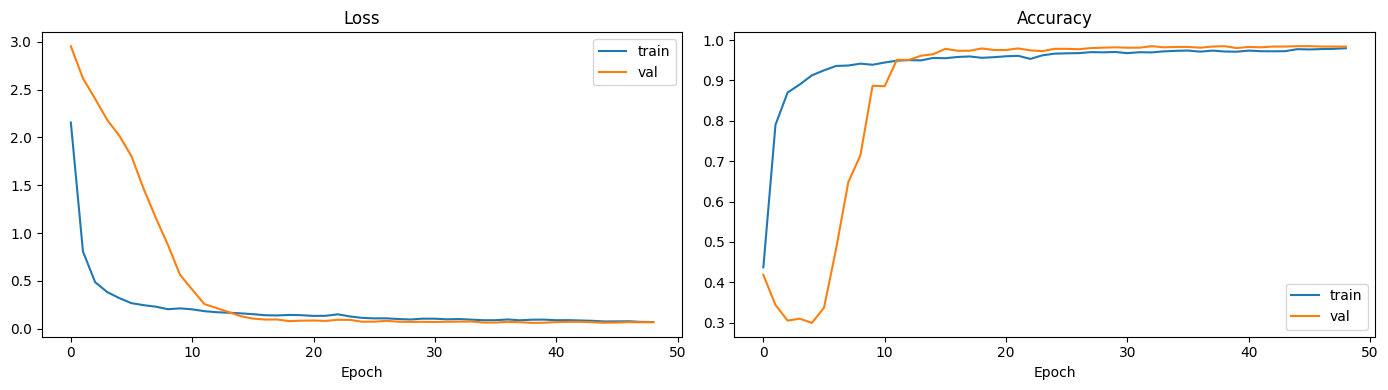

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig(LOG_OUT / 'alphabet_training_curves.png', dpi=150)
plt.show()

## 9. Evaluate on the held-out test set


In [10]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred_proba = model.predict(X_test.astype(np.float32), batch_size=BATCH, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

test_acc = accuracy_score(y_test, y_pred)
print(f'Test accuracy: {test_acc:.4f}')

label_names = [idx_to_label[i] for i in sorted(idx_to_label)]
report = classification_report(y_test, y_pred, target_names=label_names,
                                output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_df.to_csv(LOG_OUT / 'alphabet_classification_report.csv')
print('\nClassification report (per-class):')
print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))

Test accuracy: 0.9858

Classification report (per-class):
              precision    recall  f1-score   support

           A       1.00      0.94      0.97        35
           B       0.97      1.00      0.99        36
           C       1.00      1.00      1.00        34
           D       1.00      0.95      0.97        41
      DELETE       1.00      1.00      1.00        31
           E       1.00      0.97      0.99        40
           F       0.98      1.00      0.99        47
           G       1.00      1.00      1.00        40
           H       0.98      1.00      0.99        40
           I       1.00      0.97      0.99        40
           J       1.00      0.98      0.99        43
           K       1.00      1.00      1.00        45
           L       0.98      1.00      0.99        43
           M       0.93      0.93      0.93        27
           N       0.91      0.95      0.93        21
           O       0.97      0.97      0.97        38
           P       1.00

## 10. Confusion matrix


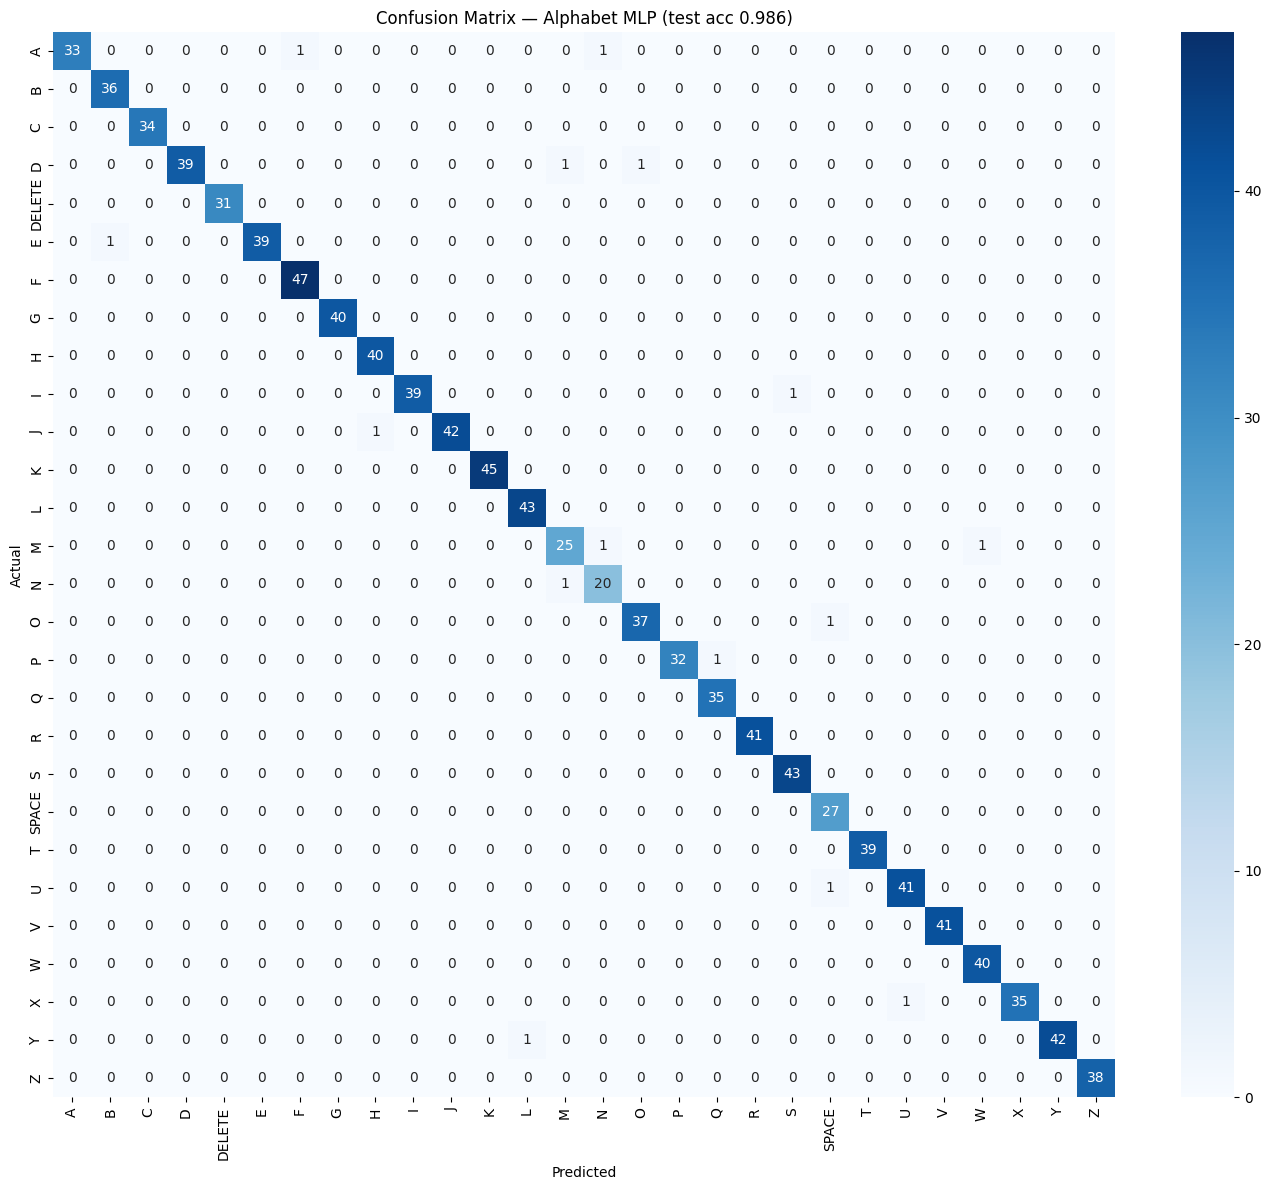

In [11]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names,
            cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix — Alphabet MLP (test acc {test_acc:.3f})')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(LOG_OUT / 'alphabet_confusion_matrix.png', dpi=150)
plt.show()

## 11. Identify weak classes and confused pairs


In [12]:
weak = [(lab, report[lab]['f1-score'])
        for lab in label_names if report[lab]['f1-score'] < 0.80]
weak.sort(key=lambda x: x[1])
print('Weak classes (F1 < 0.80):')
for lab, f1 in weak:
    print(f'  {lab:8s} F1={f1:.3f}')
if not weak:
    print('  (none — all classes above 0.80)')

print('\nMost-confused pairs (>10% of a class misclassified to another):')
for i, true_lab in enumerate(label_names):
    total = cm[i].sum()
    if total == 0: continue
    for j, pred_lab in enumerate(label_names):
        if i != j and cm[i][j] > 0.10 * total:
            pct = 100 * cm[i][j] / total
            print(f'  {true_lab} → {pred_lab}: {cm[i][j]} ({pct:.1f}%)')

Weak classes (F1 < 0.80):
  (none — all classes above 0.80)

Most-confused pairs (>10% of a class misclassified to another):


## 12. Convert to TFLite


In [13]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_bytes = converter.convert()

tflite_path = MODEL_OUT / 'alphabet_model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_bytes)
print(f'Saved {tflite_path}, {tflite_path.stat().st_size/1e3:.1f} KB')

# Parity check
interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
interpreter.allocate_tensors()
in_det  = interpreter.get_input_details()[0]
out_det = interpreter.get_output_details()[0]

n_match = 0
for i in range(20):
    sample = X_test[i:i+1].astype(np.float32)
    interpreter.set_tensor(in_det['index'], sample)
    interpreter.invoke()
    tflite_pred = np.argmax(interpreter.get_tensor(out_det['index']))
    keras_pred  = np.argmax(model.predict(sample, verbose=0))
    n_match += int(tflite_pred == keras_pred)
print(f'TFLite/Keras agreement on 20 test samples: {n_match}/20')

INFO:tensorflow:Assets written to: /tmp/tmpexr3xvmu/assets


INFO:tensorflow:Assets written to: /tmp/tmpexr3xvmu/assets


Saved artifact at '/tmp/tmpexr3xvmu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 63), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 28), dtype=tf.float32, name=None)
Captures:
  137402450879760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137402450882064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137402450882448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137402450882256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137402450880528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137402450880336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137402450881104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137402450883408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137402450883792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137402450883984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137402450882832: Tenso

W0000 00:00:1777635998.761558      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777635998.761585      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777635998.771722      57 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Saved /kaggle/working/models/alphabet_model.tflite, 69.3 KB
TFLite/Keras agreement on 20 test samples: 20/20
